# 7 — One molecule at a time

*Series: **Bayesian fluorescence decays**, notebook 7 of 8. Builds §8.1 of
`THEORY.md`.*

**What this notebook establishes.** What changes when the photons arrive as a
single-molecule stream rather than as a histogram — and, by running both,
that the answer is: almost nothing, except that the truth being measured is no
longer quite the truth in the cuvette.

---

## The stream

Everything so far assumed a cuvette: many molecules, a long acquisition, one
histogram. A confocal single-molecule experiment is different in kind.
Molecules diffuse through a spot one at a time and, while one is inside,
photons arrive in a **burst** of about a millisecond. Each photon carries

* a **macro time** — which laser pulse it followed, so when in the measurement
  it arrived, in units of the 50 ns period;
* a **micro time** — its delay after that pulse, resolved to tens of
  picoseconds.

The macro times find the bursts; the micro times of the selected photons make
the decays. `tttrlib.TTTR` is the object that holds both, and it is what a
measurement file would give.

## The selection is part of the measurement

A burst search keeps the bright crossings. Brightness depends on distance — a
molecule at short distance sends most of its light to the acceptor, whose
quantum yield and detector are not the donor's — so the population **behind
the selected bursts** is not the population in the cuvette. Both are plotted
below, and the summaries are scored against the selected one, because that is
what the decays measure.

In [1]:
import sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
import bd
bd.keep_inline()

S = bd.default_settings()
S.update(n_bursts=3000, n_bursts_donor=1200, threads=4, lam_nodes=(0.5, -0.5), seed=31)
model = bd.build_model(S)
L, rel = model['L'], model['rel']
p_true = bd.truth_distribution(model, S)
tab = bd.physics_tables(model, S, p_true, verbose=False)
stream = bd.simulate_stream(model, S, p_true, tab)
tttr = {s: bd.to_tttr(model, d) for s, d in stream.items()}
for s, d in stream.items():
    print(f"{s}: {len(d['macro']):>8d} photons over {d['duration_s']:6.1f} s, {len(d['bursts'])} molecules")
print('as a TTTR object:', len(tttr['DA'].macro_times), 'events,',
      tttr['DA'].get_header().number_of_micro_time_channels, 'micro-time channels')

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt


DA:   656940 photons over   79.0 s, 3000 molecules
D0:   178567 photons over   31.3 s, 1200 molecules
as a TTTR object: 656940 events, 1563 micro-time channels


## The burst search, and what the bursts say one at a time

`tttrlib.ranges_by_time_window` slides a window over the macro times and keeps
the stretches holding enough photons; consecutive windows that pass belong to
one molecule and are merged.

Each burst then carries its own low-precision estimate of the same distance:

$$
E^*=\frac{n_{\text{red}\mid\text{green pulse}}}{n_{\text{green}\mid\text{green pulse}}+n_{\text{red}\mid\text{green pulse}}},
\qquad
S=\frac{n_{\mid\text{green pulse}}}{n_{\text{total}}} .
$$

$E^*$ rises with transfer. $S$ is the green pulse's share of all photons: a
molecule with a working acceptor sits near one half, one that stays dark under
the red pulse goes to one. That upper band is the donor-only population, and
separating it is what PIE is for.

DA: 2746 bursts kept of 3000 molecules, 538851 photons of 656940 (82 %)
D0: 1106 bursts kept of 1200 molecules, 134554 photons of 178567 (75 %)

donor-only fraction: cuvette 0.200, selected bursts 0.199
mean R/R0:           cuvette 1.0000, selected bursts 0.9968


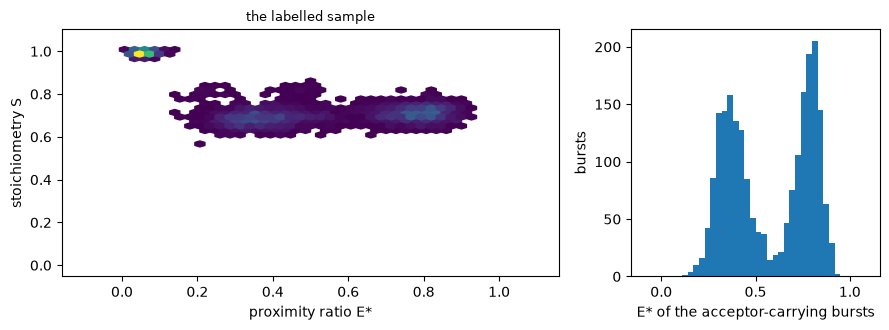

In [2]:
sel, bursts = {}, {}
for s in ('DA', 'D0'):
    sel[s], bursts[s] = bd.burst_search(model, tttr[s], S)
    n = len(tttr[s].macro_times)
    print(f'{s}: {len(bursts[s])} bursts kept of {len(stream[s]["bursts"])} molecules, '
          f'{len(sel[s])} photons of {n} ({100*len(sel[s])/n:.0f} %)')
feat = bd.burst_observables(tttr['DA'], bursts['DA'], model)
fig = bd.plot_es(feat, 'the labelled sample')
p_sel, x_sel, cnt = bd.burst_truth(model, stream['DA'], tttr['DA'], bursts['DA'])
print(f"\ndonor-only fraction: cuvette {S['donor_only_fraction']:.3f}, selected bursts {x_sel:.3f}")
print(f"mean R/R0:           cuvette {float((p_true*rel).sum()):.4f}, selected bursts {float((p_sel*rel).sum()):.4f}")

## The decays of the burst photons, and the same fit as before

The micro times of the selected photons are histogrammed on the fine axis and
rebinned onto the model's. From here nothing is new: it is the same eight
histograms, the same graph, the same Laplace-at-each-node and evidence
mixture, and the same Rule 0.

In [3]:
y = bd.assemble_data(model,
                     bd.burst_decays(model, tttr['D0'], sel['D0'], 'D0'),
                     bd.burst_decays(model, tttr['DA'], sel['DA'], 'DA'))
t0 = time.time()
nodes = [bd.fit_at_lambda(model, y, lg) for lg in S['lam_nodes']]
post = bd.mix_nodes(nodes)
ref, ref_sd = bd.poisson_reference(post, 200, 1)
dpd = post['dev'] / post['dof']
print(f'fitted in {time.time()-t0:.0f} s')
print(f'D/dof {dpd:.4f} at dof {post["dof"]}, reference {ref:.4f} +- {ref_sd:.4f}  '
      f'-> {(dpd-ref)/ref_sd:+.1f} sd')
print(f"\n{'histogram':<14}{'D/dof':>9}{'runs p':>9}")
for k in sorted(post['rows'], key=str):
    r = post['rows'][k]
    print(f"{k[0]+' '+k[1]:<14}{r['dpd']:>9.3f}{r['runs_p']:>9.3f}")

fitted in 51 s
D/dof 1.1112 at dof 1694, reference 1.0934 +- 0.0349  -> +0.5 sd

histogram         D/dof   runs p
D0 gh_vh          1.226    0.917
D0 gv_vv          1.013    0.372
D0 rh_vh          1.134    0.992
D0 rv_vv          1.150    0.985
DA gh_vh          1.256    0.456
DA gv_vv          0.953    0.443
DA rh_vh          1.034    0.580
DA rv_vv          1.123    0.909


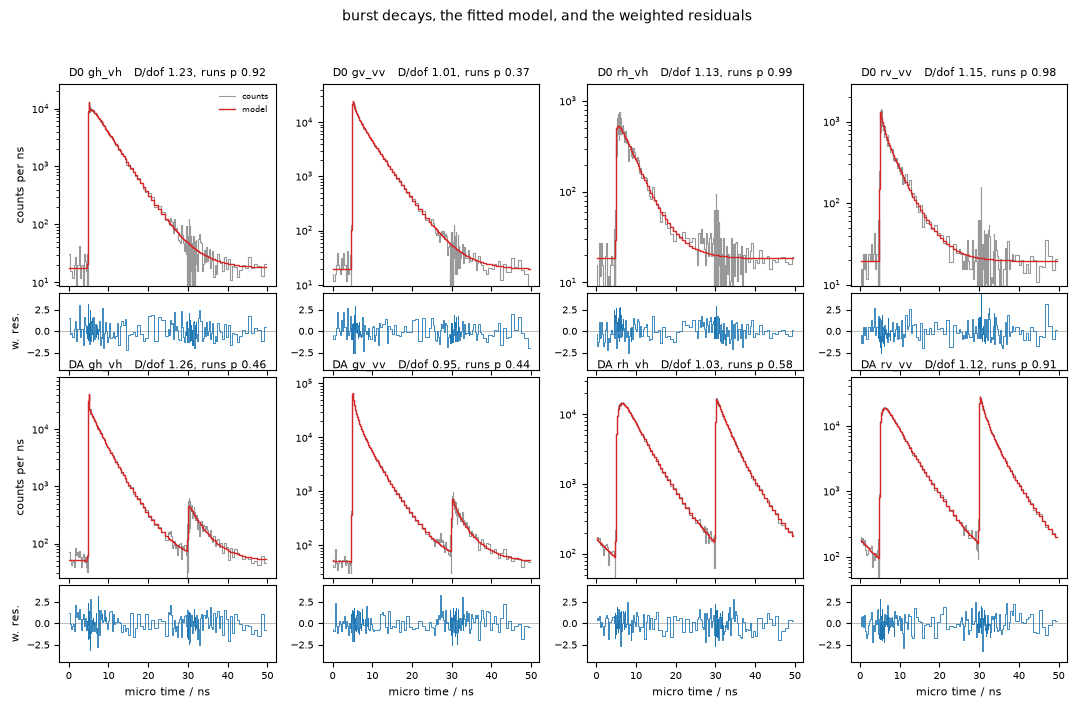

In [4]:
fig = bd.plot_decays(model, y, post, 'burst decays, the fitted model, and the weighted residuals')

quantity      truth  posterior       sd         95 % interval   covers
x_d0         0.1989     0.1790   0.0704   [+0.0409, +0.3168]   yes
mean         0.9968     1.0331   0.0590   [+0.9178, +1.1490]   yes
sd           0.2038     0.2591   0.0667   [+0.1287, +0.3901]   yes
tail         0.0459     0.1491   0.1188   [-0.0849, +0.3811]   yes
r0_d         0.3600     0.3638   0.0120   [+0.3403, +0.3872]   yes
r0_a         0.1800     0.1683   0.0112   [+0.1464, +0.1903]   yes
g            1.1500     1.1480   0.0067   [+1.1348, +1.1613]   yes


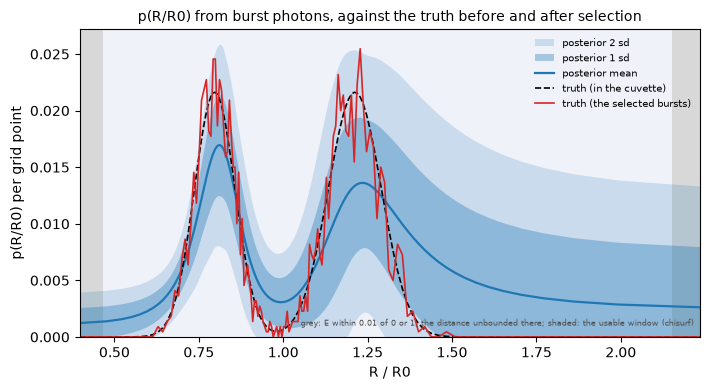

In [5]:
fig = bd.plot_pR(model, post, p_true=p_true, p_selected=p_sel, dE=0.01,
                 title='p(R/R0) from burst photons, against the truth before and after selection')
mu = float((p_sel * rel).sum())
truth = dict(x_d0=x_sel, mean=mu, sd=float(np.sqrt((p_sel * (rel - mu) ** 2).sum())),
             tail=float(p_sel[rel > 1.3].sum()), r0_d=S['r0_donor'], r0_a=S['r0_acceptor'], g=L.S.G_TRUE)
print(f"{'quantity':<10}{'truth':>9}{'posterior':>11}{'sd':>9}{'95 % interval':>22}   covers")
for r in bd.summary_table(model, post, truth):
    print(f"{r['quantity']:<10}{r['truth']:>9.4f}{r['mean']:>11.4f}{r['sd']:>9.4f}"
          f"   [{r['lo']:+.4f}, {r['hi']:+.4f}]{'':>3}{'yes' if r['inside'] else 'NO'}")

## What the experiment costs, measured against the idealised one

The question this notebook exists to answer is whether all of that — molecules
one at a time, Poisson burst sizes, background over the whole record,
scattered light, and a selection that decides which photons are used — changes
the inference relative to the cuvette version.

It was run as an A/B. Arm A is the idealised simulation of notebooks 2–6:
expected counts, one Poisson draw, the data exactly a realisation of the model
being fitted. Arm B is what this notebook does. Counts and background
fractions were matched per sample, the graph and the fit are identical, and
five seeds were run through both.

![A/B](figures/20260908T225521_s88_AB_burst_vs_ensemble.png)

*(a) the distributions of one seed; (b) each fit's deviance against its own
Poisson reference; (c) the runs tests; (d) the pulls per summary, orange for
the ensemble arm and blue for the bursts; (e) the ratio of posterior widths.*

Mean pulls, ensemble then bursts: donor-only fraction −0.50 / −0.27, mean
+0.48 / +0.38, width +0.85 / +0.75, far-tail mass +0.81 / +0.69, donor
anisotropy −0.76 / −0.62, acceptor anisotropy −1.09 / −0.64, g factor 0.00 /
−0.77. Every difference is under half a standard deviation, and the posterior
widths agree to a few percent.

**So the biases this posterior has are the method's, not the experiment's.**
The width-high, donor-only-low trade of notebook 5 is reproduced in a
simulation that has no bursts in it at all. The single-molecule experiment
costs essentially nothing beyond the photons it discards — and it offers
something the cuvette cannot, which is notebook 8.

One asymmetry is recorded without an explanation: the ensemble arm had 9 of 40
runs tests below 0.05 against the burst arm's 3 of 40, although its overall
deviance sat lower against its own reference.

## What comes next

A burst is not just a slice of a histogram. It is one molecule, and it carries
its own estimate of its own distance. Notebook 8 uses that.

**Established here.** The photon stream and its two clocks (THEORY §8.1); the
burst search; the per-burst observables; the selection effect on the truth the
decays measure; and the A/B against the idealised measurement.